# INST414 — Lab 11: Feature Importance with Speed Dating

This lab uses the OpenML version of the **SpeedDating** dataset: https://www.openml.org/d/40536

The data come from speed-dating events run at Columbia University from 2002–2004. The main paper associated with these data is Fisman, Iyengar, Kamenica, and Simonson, ["Gender Differences in Mate Selection: Evidence From a Speed Dating Experiment"](https://academic.oup.com/qje/article/121/2/673/1884033), *Quarterly Journal of Economics* (2006). A related paper using the same experiment is Fisman, Iyengar, Kamenica, and Simonson, ["Racial Preferences in Dating: Evidence from a Speed Dating Experiment"](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=610589).

This lab focuses on feature importance on the same data you used in the repeated-modeling lab. We will compare three feature-importance ideas:

- OLS coefficients
- tree-based feature importance
- SHAP values

We will also compare feature sets to see what changes when we add partner ratings or gender.

**Recommended reading:** [Introduction to Statistical Learning](https://www.statlearning.com/) — Chapter 8.2 (Bagging, Random Forests, Boosting)

**Optional resources:**
- [An introduction to explainable AI with Shapley values](https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html)
- [Understanding SHAP SAGE](https://iancovert.com/blog/understanding-shap-sage/)

## Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import statsmodels.api as sm

from IPython.display import display
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split

pd.options.display.max_columns = None
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
DATA_DIR = Path("data")

## Load The Data

In [2]:
speed = pd.read_csv(
    filepath_or_buffer=DATA_DIR / "speeddating.csv"
)
speed.shape

(8378, 123)

In [3]:
speed.head()

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,importance_same_race,importance_same_religion,d_importance_same_race,d_importance_same_religion,field,pref_o_attractive,pref_o_sincere,pref_o_intelligence,pref_o_funny,pref_o_ambitious,pref_o_shared_interests,d_pref_o_attractive,d_pref_o_sincere,d_pref_o_intelligence,d_pref_o_funny,d_pref_o_ambitious,d_pref_o_shared_interests,attractive_o,sinsere_o,intelligence_o,funny_o,ambitous_o,shared_interests_o,d_attractive_o,d_sinsere_o,d_intelligence_o,d_funny_o,d_ambitous_o,d_shared_interests_o,attractive_important,sincere_important,intellicence_important,funny_important,ambtition_important,shared_interests_important,d_attractive_important,d_sincere_important,d_intellicence_important,d_funny_important,d_ambtition_important,d_shared_interests_important,attractive,sincere,intelligence,funny,ambition,d_attractive,d_sincere,d_intelligence,d_funny,d_ambition,attractive_partner,sincere_partner,intelligence_partner,funny_partner,ambition_partner,shared_interests_partner,d_attractive_partner,d_sincere_partner,d_intelligence_partner,d_funny_partner,d_ambition_partner,d_shared_interests_partner,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,d_sports,d_tvsports,d_exercise,d_dining,d_museums,d_art,d_hiking,d_gaming,d_clubbing,d_reading,d_tv,d_theater,d_movies,d_concerts,d_music,d_shopping,d_yoga,interests_correlate,d_interests_correlate,expected_happy_with_sd_people,expected_num_interested_in_me,expected_num_matches,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,0,1.0,female,21.0,27.0,6.0,[4-6],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,[2-5],[2-5],Law,35.0,20.0,20.0,20.0,0.0,5.0,[21-100],[16-20],[16-20],[16-20],[0-15],[0-15],6.0,8.0,8.0,8.0,8.0,6.0,[6-8],[6-8],[6-8],[6-8],[6-8],[6-8],15.0,20.0,20.0,15.0,15.0,15.0,[0-15],[16-20],[16-20],[0-15],[0-15],[0-15],6.0,8.0,8.0,8.0,7.0,[6-8],[6-8],[6-8],[6-8],[6-8],6.0,9.0,7.0,7.0,6.0,5.0,[6-8],[9-10],[6-8],[6-8],[6-8],[0-5],9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,[9-10],[0-5],[6-8],[9-10],[0-5],[0-5],[0-5],[0-5],[0-5],[6-8],[9-10],[0-5],[9-10],[9-10],[9-10],[6-8],[0-5],0.14,[0-0.33],3.0,2.0,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1,0,0
1,0,1.0,female,21.0,22.0,1.0,[0-1],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,[2-5],[2-5],Law,60.0,0.0,0.0,40.0,0.0,0.0,[21-100],[0-15],[0-15],[21-100],[0-15],[0-15],7.0,8.0,10.0,7.0,7.0,5.0,[6-8],[6-8],[9-10],[6-8],[6-8],[0-5],15.0,20.0,20.0,15.0,15.0,15.0,[0-15],[16-20],[16-20],[0-15],[0-15],[0-15],6.0,8.0,8.0,8.0,7.0,[6-8],[6-8],[6-8],[6-8],[6-8],7.0,8.0,7.0,8.0,5.0,6.0,[6-8],[6-8],[6-8],[6-8],[0-5],[6-8],9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,[9-10],[0-5],[6-8],[9-10],[0-5],[0-5],[0-5],[0-5],[0-5],[6-8],[9-10],[0-5],[9-10],[9-10],[9-10],[6-8],[0-5],0.54,[0.33-1],3.0,2.0,4.0,[0-4],[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0,1,0,0
2,1,1.0,female,21.0,22.0,1.0,[0-1],Asian/Pacific Islander/Asian-American,Asian/Pacific Islander/Asian-American,1,2.0,4.0,[2-5],[2-5],Law,19.0,18.0,19.0,18.0,14.0,12.0,[16-20],[16-20],[16-20],[16-20],[0-15],[0-15],10.0,10.0,10.0,10.0,10.0,10.0,[9-10],[9-10],[9-10],[9-10],[9-10],[9-10],15.0,20.0,20.0,15.0,15.0,15.0,[0-15],[16-20],[16-20],[0-15],[0-15],[0-15],6.0,8.0,8.0,8.0,7.0,[6-8],[6-8],[6-8],[6-8],[6-8],5.0,8.0,9.0,8.0,5.0,7.0,[0-5],[6-8],[9-10],[6-8],[0-5],[6-8],9.0,2.0,8.0,9.0,1.0,1.0,5.0,1.0,5.0,6.0,9.0,1.0,10.0,10.0,9.0,8.0,1.0,[9-10],[0-5],[6-8],[9-10],[0-5],[0-5],[0-5],[0-5],[0-5],[6-8],[9-10],[0-5],[9-10],[9-10],[9-10],[6-8],[0-5],0.16,[0-0.33],3.0,2.0,4.0,[0-4],[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0,1,1,1
3,0,1.0,female,21.0,23.0,2.0,[2-3],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,2.0,4.0,[2-5],[2-5],Law,30.0,5.0,15.0,40.0,5.0,5.0,[

## Unit Of Analysis And Outcome

Each row is one dater evaluating one partner.

Important columns:

- `decision`: whether this dater said yes
- `decision_o`: whether the partner said yes
- `match`: whether both people said yes
- `gender`: gender of this dater
- `age`, `race`, preferences, and self-ratings: attributes of this dater
- `age_o`, `race_o`, and variables ending in `_o`: attributes or ratings from the partner side
- variables ending in `_partner`: this dater's rating of the partner

This lab predicts `decision`, not `match`. The `match` outcome is symmetric because a mutual match is shared by both sides of the pair. The `decision` outcome is directional: it is this dater's choice.

In [4]:
speed[['decision', 'decision_o', 'match', 'gender', 'age', 'age_o', 'd_age']].head()

,decision,decision_o,match,gender,age,age_o,d_age
0,1,0,0,female,21.0,27.0,6.0
1,1,0,0,female,21.0,22.0,1.0
2,1,1,1,female,21.0,22.0,1.0
3,1,1,1,female,21.0,23.0,2.0
4,1,1,1,female,21.0,24.0,3.0


In [5]:
# Base rate: share of rows where the dater said yes.
speed['decision'].mean()

np.float64(0.41990928622582957)

In [6]:
# Decision rates by dater gender.
speed.groupby('gender')['decision'].mean()

gender
female    0.365440
male      0.474249
Name: decision, dtype: float64

## Feature Sets

The feature sets build up in stages.

The first feature set uses basic date context, the dater's own self-ratings, and the dater's own preferences.

The second feature set adds the partner's ratings of the dater. These variables describe how the partner rated this dater after the date. They are likely to be predictive, but they are also different from the dater's own evaluation of the partner.

The third feature set adds `gender_male`, which lets the model use the dater's gender directly.

`interests_correlate` measures how similar the dater's and partner's interest profiles are. It is a compatibility measure based on ratings of interests such as sports, dining, museums, music, shopping, and yoga.

`sincerity` variables are prepared but held out for the lab tasks.

Do not use `decision_o` or `match` as features. Those variables are too close to the outcome.

In [7]:
basic_features = [
    'age',
    'age_o',
    'd_age',
    'interests_correlate'
]

own_rating_features = [
    'attractive',
    'intelligence',
    'funny',
    'ambition'
]

own_preference_features = [
    'attractive_important',
    'intellicence_important',
    'funny_important',
    'ambtition_important',
    'shared_interests_important'
]

partner_rating_features = [
    'attractive_partner',
    'intelligence_partner',
    'funny_partner',
    'ambition_partner',
    'shared_interests_partner'
]

sincerity_features = [
    'sincere',
    'sincere_important',
    'sincere_partner'
]

The feature lists stay broken out by type so you can see what the model is using:

- basic date context
- the dater's own ratings
- the dater's own preferences
- the partner's ratings of the dater
- the sincerity variables held out for the lab tasks

In [8]:
feature_group_preview = pd.DataFrame([
    {'feature_group': 'basic_features', 'columns': ', '.join(basic_features)},
    {'feature_group': 'own_rating_features', 'columns': ', '.join(own_rating_features)},
    {'feature_group': 'own_preference_features', 'columns': ', '.join(own_preference_features)},
    {'feature_group': 'partner_rating_features', 'columns': ', '.join(partner_rating_features)},
    {'feature_group': 'sincerity_features', 'columns': ', '.join(sincerity_features)}
])

display(feature_group_preview)

,feature_group,columns
0,basic_features,"age, age_o, d_age, interests_correlate"
1,own_rating_features,"attractive, intelligence, funny, ambition"
2,own_preference_features,"attractive_important, intellicence_important, ..."
3,partner_rating_features,"attractive_partner, intelligence_partner, funn..."
4,sincerity_features,"sincere, sincere_important, sincere_partner"


## Prepare A Modeling Dataset

For this lab, missing values in the selected feature columns are filled with `0`. This keeps all rows in the dataset and keeps the focus on the repeated modeling workflow. In a real project, the missing-data strategy would need more attention.

In [9]:
selected_columns = (
    ['decision', 'gender']
    + basic_features
    + own_rating_features
    + own_preference_features
    + partner_rating_features
    + sincerity_features
)

model_data = speed[selected_columns].copy()

# Create a numeric gender variable using pandas.
gender_dummies = pd.get_dummies(model_data['gender'])
model_data['gender_male'] = gender_dummies['male']

numeric_columns = (
    ['decision']
    + basic_features
    + own_rating_features
    + own_preference_features
    + partner_rating_features
    + sincerity_features
    + ['gender_male']
)
for column in numeric_columns:
    model_data[column] = pd.to_numeric(model_data[column], errors='coerce')

# Fill missing feature values with 0 for this lab.
model_data = model_data.fillna(0)

model_data['decision'] = model_data['decision'].astype(int)
model_data['gender_male'] = model_data['gender_male'].astype(int)

model_data.head()

,decision,gender,age,age_o,d_age,interests_correlate,attractive,intelligence,funny,ambition,attractive_important,intellicence_important,funny_important,ambtition_important,shared_interests_important,attractive_partner,intelligence_partner,funny_partner,ambition_partner,shared_interests_partner,sincere,sincere_important,sincere_partner,gender_male
0,1,female,21.0,27.0,6.0,0.14,6.0,8.0,8.0,7.0,15.0,20.0,15.0,15.0,15.0,6.0,7.0,7.0,6.0,5.0,8.0,20.0,9.0,0
1,1,female,21.0,22.0,1.0,0.54,6.0,8.0,8.0,7.0,15.0,20.0,15.0,15.0,15.0,7.0,7.0,8.0,5.0,6.0,8.0,20.0,8.0,0
2,1,female,21.0,22.0,1.0,0.16,6.0,8.0,8.0,7.0,15.0,20.0,15.0,15.0,15.0,5.0,9.0,8.0,5.0,7.0,8.0,20.0,8.0,0
3,1,female,21.0,23.0,2.0,0.61,6.0,8.0,8.0,7.0,15.0,20.0,15.0,15.0,15.0,7.0,8.0,7.0,6.0,8.0,8.0,20.0,6.0,0
4,1,female,21.0,24.0,3.0,0.21,6.0,8.0,8.0,7.0,15.0,20.0,15.0,15.0,15.0,5.0,7.0,7.0,6.0,6.0,8.0,20.0,6.0,0


In [10]:
model_data.shape

(8378, 24)

## Create One Train/Test Split

Use one train/test split and reuse it for all model specifications. This keeps the model comparisons clean because each model is evaluated on the same test cases.

In [11]:
train, test = train_test_split(
    model_data,
    test_size=0.30,
    random_state=414,
    stratify=model_data['decision']
)

train.shape, test.shape

((5864, 24), (2514, 24))

## Abstract The Repeated Parts

When a workflow repeats, create objects that describe what changes and objects that store what comes out.

Objects used here:

- `feature_sets`: named feature lists
- `model_specs`: one row of instructions per model to fit
- `best_models`: fitted models stored by name
- `model_results`: summary rows with best settings and test performance
- `predictions`: test set plus predicted probabilities

This pattern is useful because model fitting, prediction, and evaluation all need the same labels and feature lists.

In [12]:
feature_sets = {
    'own_profile': basic_features + own_rating_features + own_preference_features,
    'own_profile_plus_partner_ratings_of_dater': basic_features + own_rating_features + own_preference_features + partner_rating_features,
    'own_profile_plus_partner_ratings_of_dater_plus_gender': basic_features + own_rating_features + own_preference_features + partner_rating_features + ['gender_male']
}

model_specs = [
    {
        'model_label': 'own_profile',
        'features': feature_sets['own_profile']
    },
    {
        'model_label': 'own_profile_plus_partner_ratings_of_dater',
        'features': feature_sets['own_profile_plus_partner_ratings_of_dater']
    },
    {
        'model_label': 'own_profile_plus_partner_ratings_of_dater_plus_gender',
        'features': feature_sets['own_profile_plus_partner_ratings_of_dater_plus_gender']
    }
]

param_grid = {
    'learning_rate': [0.03, 0.10, 0.30],
    'max_depth': [1, 2, 3],
    'n_estimators': [50, 100, 200]
}

In [13]:
# This is what the model specification object looks like.
model_specs

[{'model_label': 'own_profile',
  'features': ['age',
   'age_o',
   'd_age',
   'interests_correlate',
   'attractive',
   'intelligence',
   'funny',
   'ambition',
   'attractive_important',
   'intellicence_important',
   'funny_important',
   'ambtition_important',
   'shared_interests_important']},
 {'model_label': 'own_profile_plus_partner_ratings_of_dater',
  'features': ['age',
   'age_o',
   'd_age',
   'interests_correlate',
   'attractive',
   'intelligence',
   'funny',
   'ambition',
   'attractive_important',
   'intellicence_important',
   'funny_important',
   'ambtition_important',
   'shared_interests_important',
   'attractive_partner',
   'intelligence_partner',
   'funny_partner',
   'ambition_partner',
   'shared_interests_partner']},
 {'model_label': 'own_profile_plus_partner_ratings_of_dater_plus_gender',
  'features': ['age',
   'age_o',
   'd_age',
   'interests_correlate',
   'attractive',
   'intelligence',
   'funny',
   'ambition',
   'attractive_importan

## Tune The Models

Each model specification gets the same tuning process:

1. Use `GridSearchCV` on the training set.
2. Tune `learning_rate`, `max_depth`, and `n_estimators`.
3. Store the best fitted model.
4. Add predicted probabilities to the shared test-set table.
5. Store a summary row.

In [14]:
best_models = {}
model_results = []
predictions = test.copy()

for spec in model_specs:
    # Pull the model label and feature list out of the specification.
    model_label = spec['model_label']
    features = spec['features']

    # Tune learning_rate, max_depth, and n_estimators using cross-validation on the training set.
    grid_search = GridSearchCV(
        estimator=GradientBoostingClassifier(random_state=414),
        param_grid=param_grid,
        scoring='roc_auc',
        cv=5
    )

    # Fit only on the training set.
    grid_search.fit(X=train[features], y=train['decision'])

    # Store the best fitted model so it can be reused later.
    best_models[model_label] = grid_search.best_estimator_

    # Add test-set predicted probabilities to one shared predictions table.
    pred_col = 'pred_' + model_label
    predictions[pred_col] = grid_search.predict_proba(X=predictions[features])[:, 1]

    # Evaluate the chosen model on the test set.
    test_auc = roc_auc_score(
        y_true=predictions['decision'],
        y_score=predictions[pred_col]
    )

    # Store one row of results for this model.
    model_results.append({
        'model_label': model_label,
        'best_learning_rate': grid_search.best_params_['learning_rate'],
        'best_max_depth': grid_search.best_params_['max_depth'],
        'best_n_estimators': grid_search.best_params_['n_estimators'],
        'test_auc': test_auc
    })

model_results = pd.DataFrame(model_results)
model_results

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=414),
             param_grid={'learning_rate': [0.03, 0.1, 0.3],
                         'max_depth': [1, 2, 3],
                         'n_estimators': [50, 100, 200]},
             scoring='roc_auc')

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=414),
             param_grid={'learning_rate': [0.03, 0.1, 0.3],
                         'max_depth': [1, 2, 3],
                         'n_estimators': [50, 100, 200]},
             scoring='roc_auc')

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=414),
             param_grid={'learning_rate': [0.03, 0.1, 0.3],
                         'max_depth': [1, 2, 3],
                         'n_estimators': [50, 100, 200]},
             scoring='roc_auc')

,model_label,best_learning_rate,best_max_depth,best_n_estimators,test_auc
0,own_profile,0.3,3,200,0.685133
1,own_profile_plus_partner_ratings_of_dater,0.3,3,200,0.876539
2,own_profile_plus_partner_ratings_of_dater_plus...,0.3,3,200,0.875574


## Evaluate A Top-K Rule

Suppose the app can only show a limited number of high-probability potential dates. A top-k rule flags the highest-scoring rows.

Here, `k = 250`, so each model flags the 250 rows with the highest predicted probability.

In [15]:
k = 250

topk_results = []

for spec in model_specs:
    model_label = spec['model_label']
    pred_col = 'pred_' + model_label
    flag_col = 'flag_top_' + model_label

    topk_index = predictions.sort_values(by=pred_col, ascending=False).head(k).index
    predictions[flag_col] = 0
    predictions.loc[topk_index, flag_col] = 1

    precision_at_k = predictions.loc[topk_index, 'decision'].mean()

    topk_results.append({
        'model_label': model_label,
        'k': k,
        'share_flagged': k / len(predictions),
        'precision_at_k': precision_at_k
    })

topk_results = pd.DataFrame(topk_results)
topk_results

,model_label,k,share_flagged,precision_at_k
0,own_profile,250,0.099443,0.716
1,own_profile_plus_partner_ratings_of_dater,250,0.099443,0.920
2,own_profile_plus_partner_ratings_of_dater_plus...,250,0.099443,0.920


## Fairness Analysis By Gender

Now compare the top-k flags by gender.

Demographic parity compares the rate at which groups receive the positive prediction. Here, the positive prediction is being flagged in the top 250.

For each model, compute:

- gender-specific AUC
- average predicted probability among flagged rows
- flag rate: `P(flagged = 1 | gender)`
- PPV: among flagged rows, the share where `decision = 1`
- FPR: among rows where `decision = 0`, the share flagged
- FNR: among rows where `decision = 1`, the share not flagged

In [16]:
fairness_rows = []

for spec in model_specs:
    model_label = spec['model_label']
    pred_col = 'pred_' + model_label
    flag_col = 'flag_top_' + model_label

    for gender in ['female', 'male']:
        group = predictions[predictions['gender'] == gender]

        tp = ((group[flag_col] == 1) & (group['decision'] == 1)).sum()
        fp = ((group[flag_col] == 1) & (group['decision'] == 0)).sum()
        fn = ((group[flag_col] == 0) & (group['decision'] == 1)).sum()
        tn = ((group[flag_col] == 0) & (group['decision'] == 0)).sum()

        gender_auc = roc_auc_score(
            y_true=group['decision'],
            y_score=group[pred_col]
        )

        fairness_rows.append({
            'model_label': model_label,
            'gender': gender,
            'AUC': gender_auc,
            'avg_pred_prob_flagged': group[group[flag_col] == 1][pred_col].mean(),
            'flag_rate': group[flag_col].mean(),
            'PPV': tp / (tp + fp),
            'FPR': fp / (fp + tn),
            'FNR': fn / (fn + tp)
        })

fairness_results = pd.DataFrame(fairness_rows)
fairness_results

,model_label,gender,AUC,avg_pred_prob_flagged,flag_rate,PPV,FPR,FNR
0,own_profile,female,0.679354,0.801748,0.052936,0.671875,0.027415,0.902935
1,own_profile,male,0.680348,0.826271,0.142529,0.731183,0.072254,0.778140
2,own_profile_plus_partner_ratings_of_dater,female,0.872608,0.955751,0.067825,0.865854,0.014360,0.839729
3,own_profile_plus_partner_ratings_of_dater,male,0.877491,0.963481,0.128736,0.946429,0.013006,0.740620
4,own_profile_plus_partner_ratings_of_dater_plus...,female,0.875714,0.956185,0.072787,0.875000,0.014360,0.826185
5,own_profile_plus_partner_ratings_of_dater_plus...,male,0.872479,0.964587,0.124138,0.944444,0.013006,0.750408


## Feature Importance: OLS Coefficients

OLS gives a clean baseline for interpretation because each coefficient tells us how the prediction changes when that feature changes, holding the other features fixed.

We fit the full feature set so we can compare the sign and size of the coefficients to the tree-based importance measures below.

,feature,coef,abs_coef
13,attractive_partner,0.087382,0.087382
18,gender_male,0.048326,0.048326
15,funny_partner,0.032410,0.032410
17,shared_interests_partner,0.027098,0.027098
16,ambition_partner,-0.017857,0.017857
14,intelligence_partner,-0.011757,0.011757
5,intelligence,-0.010438,0.010438
7,ambition,0.008372,0.008372
4,attractive,-0.003657,0.003657
3,interests_correlate,-0.002944,0.002944


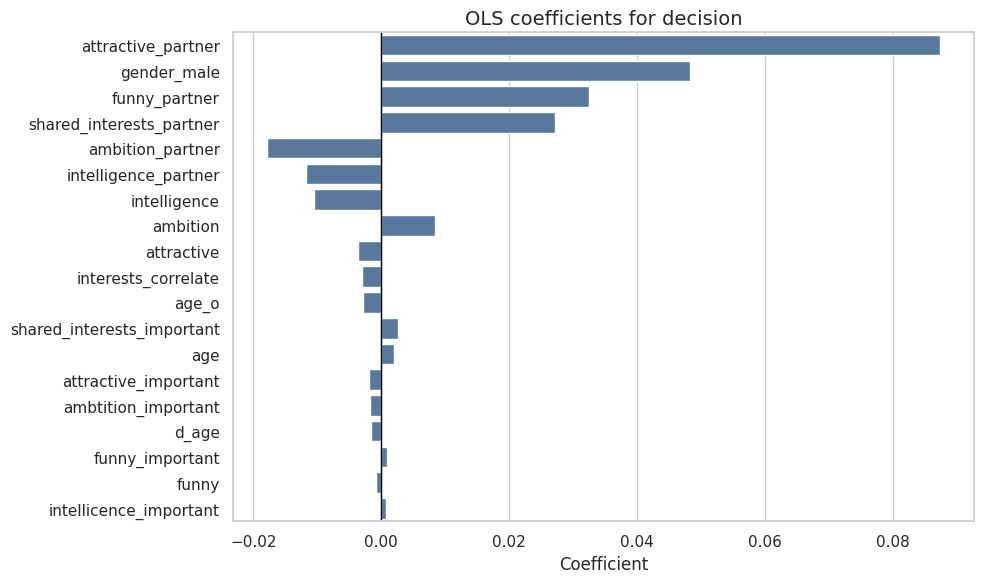

In [17]:
full_model_label = 'own_profile_plus_partner_ratings_of_dater_plus_gender'
full_features = feature_sets[full_model_label]

ols_X_train = sm.add_constant(train[full_features], has_constant='add')
ols_X_test = sm.add_constant(test[full_features], has_constant='add')
ols_model = sm.OLS(train['decision'], ols_X_train).fit()
predictions['pred_ols'] = ols_model.predict(ols_X_test)

ols_table = (
    pd.DataFrame({
        'feature': full_features,
        'coef': ols_model.params[full_features].values
    })
    .assign(abs_coef=lambda frame: frame['coef'].abs())
    .sort_values('abs_coef', ascending=False)
)

display(ols_table.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=ols_table,
    y='feature',
    x='coef',
    color='#4C78A8'
)
plt.axvline(0, color='black', linewidth=1)
plt.title('OLS coefficients for decision')
plt.xlabel('Coefficient')
plt.ylabel('')
plt.tight_layout()
plt.show();

## Feature Importance: OLS Coefficients By Gender

The same coefficient idea can be fit separately for women and men.

Here we drop the gender indicator and fit the same model twice, once on the female rows and once on the male rows. The attributes stay broken out into the same groups as above, so it is easier to compare whether the model seems to rely on the same features in the same way for both groups.

gender,feature_group,feature,female,male,abs_mean_coef
3,basic,interests_correlate,0.022115,-0.032726,0.027420
0,basic,age,0.003269,0.001476,0.002372
1,basic,age_o,-0.002979,-0.001504,0.002242
2,basic,d_age,-0.001190,-0.000788,0.000989
8,own preferences,shared_interests_important,0.001903,0.003547,0.002725
5,own preferences,attractive_important,-0.000920,-0.001835,0.001378
4,own preferences,ambtition_important,-0.000306,-0.002434,0.001370
6,own preferences,funny_important,0.002430,0.000268,0.001349
7,own preferences,intellicence_important,0.001841,0.000088,0.000964
11,own ratings,funny,-0.012367,0.016386,0.014376


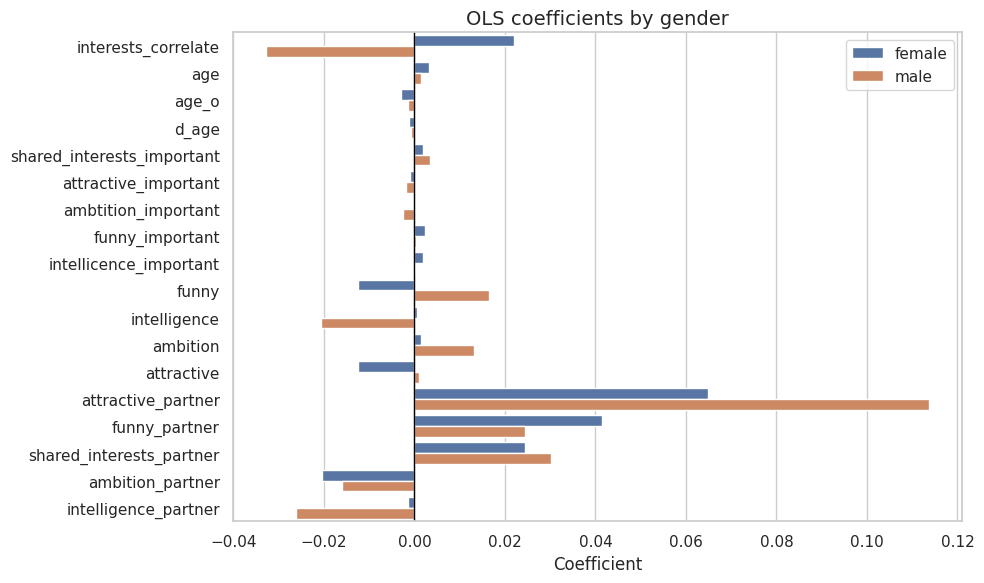

In [18]:
gender_features = basic_features + own_rating_features + own_preference_features + partner_rating_features
feature_group_lookup = {}
for feature in basic_features:
    feature_group_lookup[feature] = 'basic'
for feature in own_rating_features:
    feature_group_lookup[feature] = 'own ratings'
for feature in own_preference_features:
    feature_group_lookup[feature] = 'own preferences'
for feature in partner_rating_features:
    feature_group_lookup[feature] = 'partner ratings'

gender_models = {}
gender_rows = []

for gender in ['female', 'male']:
    gender_train = train[train['gender'] == gender]
    gender_test = test[test['gender'] == gender]

    gender_X_train = sm.add_constant(gender_train[gender_features], has_constant='add')
    gender_X_test = sm.add_constant(gender_test[gender_features], has_constant='add')
    gender_model = sm.OLS(gender_train['decision'], gender_X_train).fit()
    gender_models[gender] = gender_model

    for feature in gender_features:
        gender_rows.append({
            'feature': feature,
            'feature_group': feature_group_lookup[feature],
            'gender': gender,
            'coef': gender_model.params[feature]
        })

gender_coef_table = (
    pd.DataFrame(gender_rows)
    .pivot(index=['feature_group', 'feature'], columns='gender', values='coef')
    .reset_index()
    .assign(abs_mean_coef=lambda frame: frame[['female', 'male']].abs().mean(axis=1))
    .sort_values(['feature_group', 'abs_mean_coef'], ascending=[True, False])
)

display(gender_coef_table.head(10))

gender_coef_long = (
    gender_coef_table
    .drop(columns='abs_mean_coef')
    .melt(id_vars=['feature_group', 'feature'], var_name='gender', value_name='coef')
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=gender_coef_long,
    y='feature',
    x='coef',
    hue='gender',
    dodge=True
)
plt.axvline(0, color='black', linewidth=1)
plt.title('OLS coefficients by gender')
plt.xlabel('Coefficient')
plt.ylabel('')
plt.legend(title='')
plt.tight_layout()
plt.show();

## Feature Importance: Tree Model

Trees do not have coefficients. Instead, importance comes from how much each feature helps split the data.

Here we use the best tuned gradient boosting model for the full feature set.

,feature,importance
13,attractive_partner,0.414954
17,shared_interests_partner,0.082754
15,funny_partner,0.074653
8,attractive_important,0.052396
9,intellicence_important,0.044611
10,funny_important,0.036474
12,shared_interests_important,0.036209
0,age,0.031789
5,intelligence,0.029063
4,attractive,0.028482


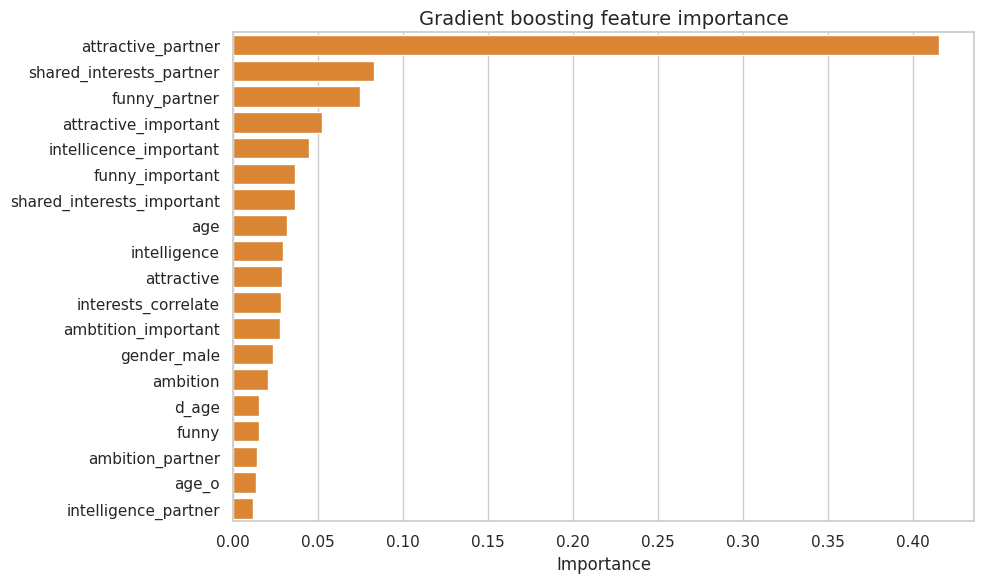

In [19]:
gb_full_model = best_models[full_model_label]

tree_importance = (
    pd.DataFrame({
        'feature': full_features,
        'importance': gb_full_model.feature_importances_
    })
    .sort_values('importance', ascending=False)
)

display(tree_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=tree_importance,
    y='feature',
    x='importance',
    color='#F58518'
)
plt.title('Gradient boosting feature importance')
plt.xlabel('Importance')
plt.ylabel('')
plt.tight_layout()
plt.show();

## Feature Importance: SHAP

SHAP explains one prediction at a time by starting from a baseline and then adding feature contributions.

We will use the same full gradient boosting model and show both a global summary plot and dependence plots for age.

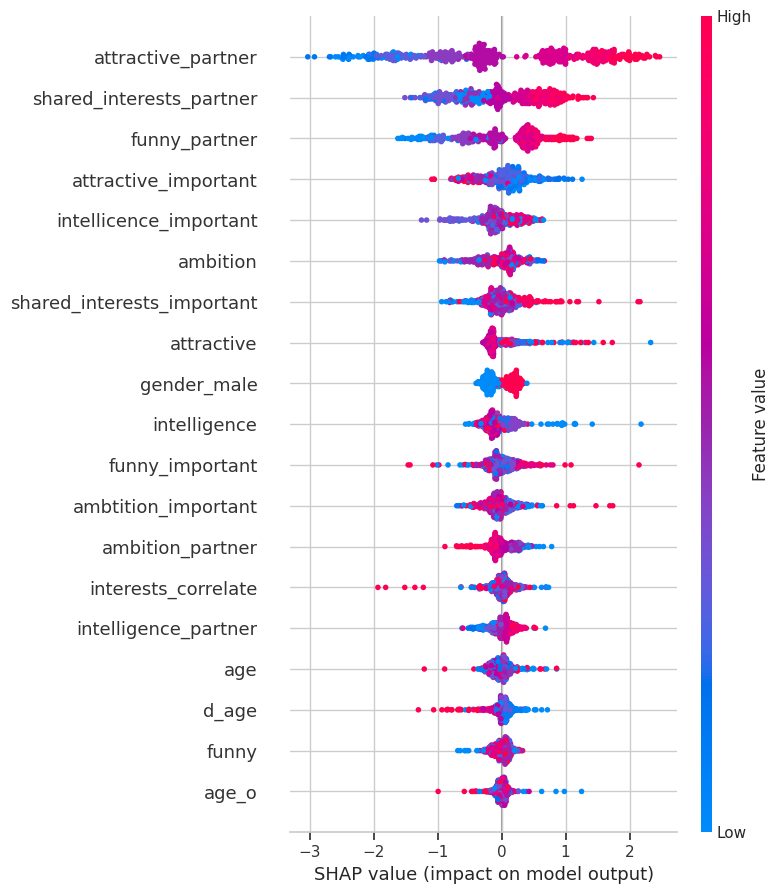

In [20]:
shap_sample = test.sample(n=min(500, len(test)), random_state=414)[full_features]
explainer = shap.TreeExplainer(gb_full_model)
shap_values = explainer.shap_values(shap_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]

if hasattr(shap_values, "values"):
    shap_values = shap_values.values

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, shap_sample, show=False)
plt.tight_layout()
plt.show();

<Figure size 1000x600 with 0 Axes>

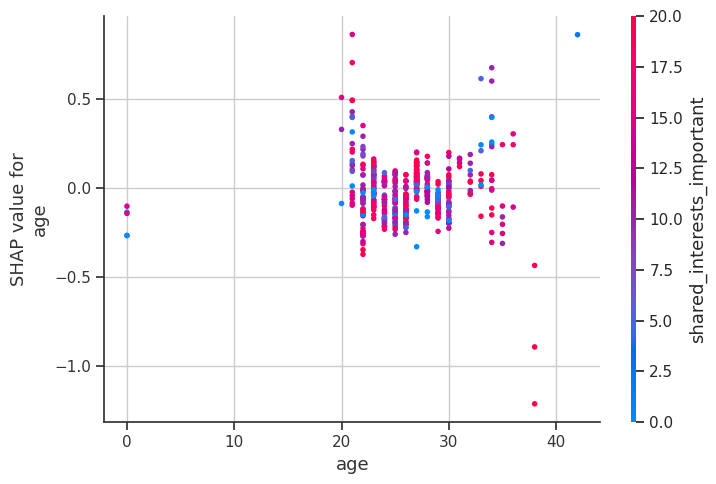

<Figure size 1000x600 with 0 Axes>

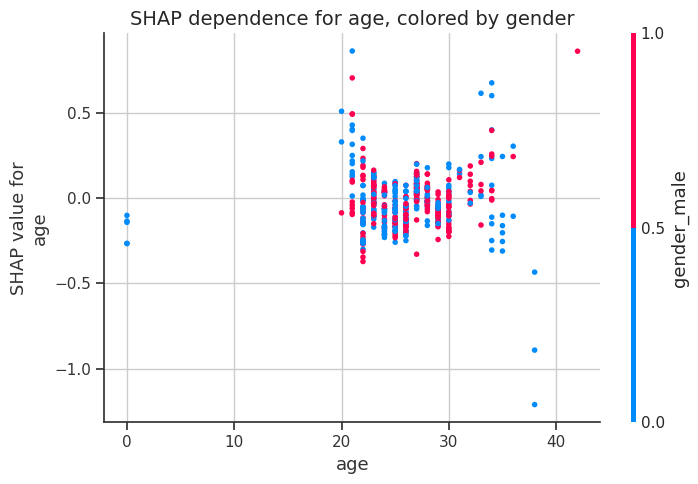

In [21]:
plt.figure(figsize=(10, 6))
shap.dependence_plot('age', shap_values, shap_sample, show=False)
plt.tight_layout()
plt.show();

plt.figure(figsize=(10, 6))
shap.dependence_plot('age', shap_values, shap_sample, interaction_index='gender_male', show=False)
plt.title('SHAP dependence for age, colored by gender')
plt.tight_layout()
plt.show();

## Compare The Feature Sets

The model results table gives an ablation-style view of feature importance: what changes when partner ratings or gender are added?

A useful question to ask is whether the model gains a lot from a feature group and whether the gender gap changes when that group is removed.

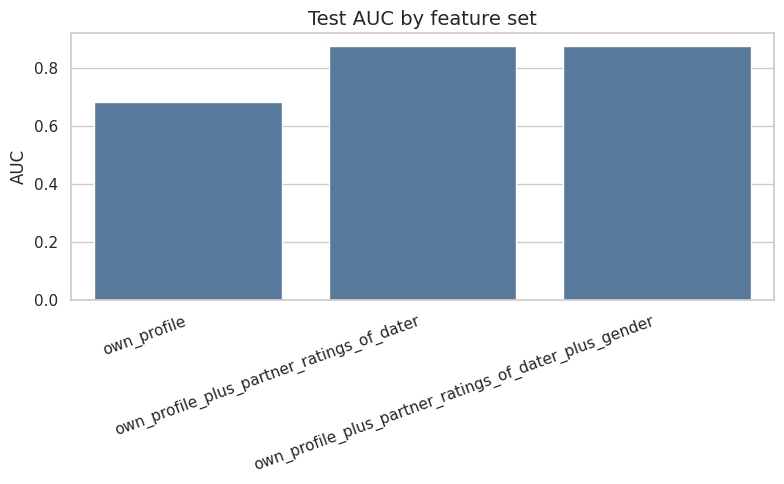

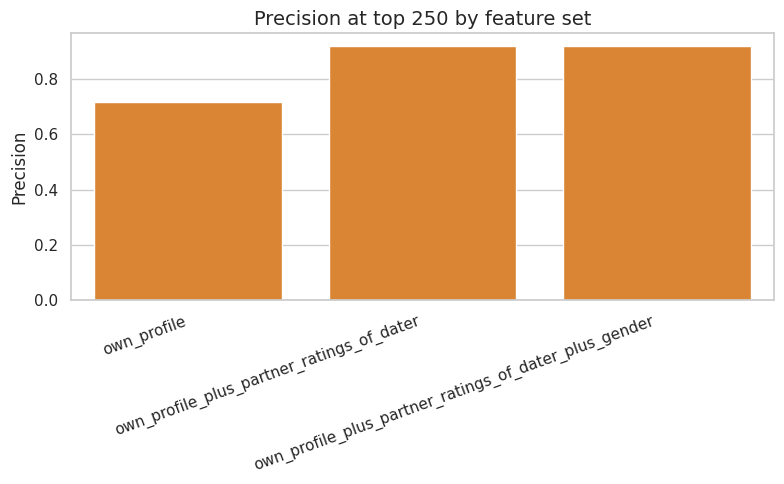

In [22]:
plt.figure(figsize=(8, 5))
sns.barplot(data=model_results, x='model_label', y='test_auc', color='#4C78A8')
plt.xticks(rotation=20, ha='right')
plt.title('Test AUC by feature set')
plt.xlabel('')
plt.ylabel('AUC')
plt.tight_layout()
plt.show();

plt.figure(figsize=(8, 5))
sns.barplot(data=topk_results, x='model_label', y='precision_at_k', color='#F58518')
plt.xticks(rotation=20, ha='right')
plt.title('Precision at top 250 by feature set')
plt.xlabel('')
plt.ylabel('Precision')
plt.tight_layout()
plt.show();

## Fairness By Gender

Compare the full model to the version without gender.

The table includes AUC, the average predicted probability among flagged rows, the flag rate, PPV, FPR, and FNR.

,model_label,gender,AUC,avg_pred_prob_flagged,flag_rate,PPV,FPR,FNR
2,own_profile_plus_partner_ratings_of_dater,female,0.872608,0.955751,0.067825,0.865854,0.014360,0.839729
3,own_profile_plus_partner_ratings_of_dater,male,0.877491,0.963481,0.128736,0.946429,0.013006,0.740620
4,own_profile_plus_partner_ratings_of_dater_plus...,female,0.875714,0.956185,0.072787,0.875000,0.014360,0.826185
5,own_profile_plus_partner_ratings_of_dater_plus...,male,0.872479,0.964587,0.124138,0.944444,0.013006,0.750408


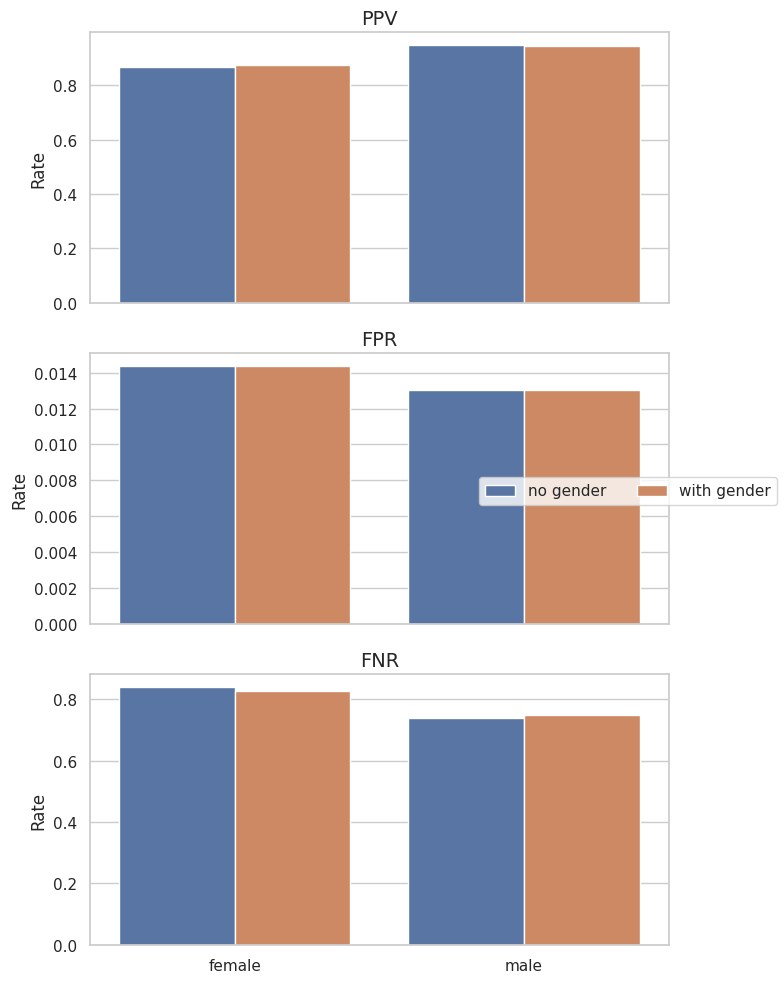

In [23]:
fairness_compare = fairness_results[
    fairness_results['model_label'].isin([
        'own_profile_plus_partner_ratings_of_dater',
        'own_profile_plus_partner_ratings_of_dater_plus_gender'
    ])
].copy()

display(fairness_compare)

fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
for ax, metric_name in zip(axes, ['PPV', 'FPR', 'FNR']):
    sns.barplot(
        data=fairness_compare,
        x='gender',
        y=metric_name,
        hue='model_label',
        ax=ax
    )
    ax.set_title(metric_name)
    ax.set_xlabel('')
    ax.set_ylabel('Rate')
    if ax.legend_ is not None:
        ax.legend_.remove()

fig.legend(
    handles=axes[0].get_legend_handles_labels()[0],
    labels=['no gender', 'with gender'],
    loc='center right',
    ncol=2
)
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show();